<a href="https://colab.research.google.com/github/tradingwithme/Works-w-ML-and-w-o-ML/blob/main/Healthcare%20Risk%20Equilibrium%20Technicals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Healthcare Risk Equilibrium Technicals**  

---

## **Introduction**

This document presents a unified overview of a healthcare risk modeling framework inspired by Mario Schlosser’s Healthcare Risk Equilibrium Theorem. It integrates mathematical foundations, conceptual explanations, a synthetic example, and executable Python code suitable for Google Colab.

The goal is to demonstrate how iterative risk propagation and eigenvector based equilibrium methods can be applied to patient similarity networks to produce fairer, more stable, and more interpretable healthcare risk scores.

---

## **Overview**

Traditional healthcare risk scores often rely on static snapshots of patient data. These models fail to capture how risk evolves over time or how patients influence one another through shared clinical, environmental, or social factors.

To address this, I model patients as nodes in a graph. Edges represent similarity across features such as:

- comorbidities  
- medication histories  
- demographic factors  
- environmental exposures  
- social determinants  

Risk is treated as a **dynamic vector** that updates iteratively based on both individual baseline risk and propagated influence from similar patients.

---

## Iterative Risk Propagation Model
I define the update rule:

$$
r_{t+1} = \alpha W r_t + (1 - \alpha)b
$$

Where:

- \( W \) is a row normalized adjacency matrix  
- \( b \) is the baseline clinical risk vector  
- \( \alpha \in (0,1) \) controls propagation strength  
- \( r_t \) is the risk vector at iteration \( t \)

This process continues until convergence.

---

## Equilibrium Solution

As \( t \to \infty \), the system converges to:

$$
r^{*} = (I - \alpha W)^{-1} b
$$

This equilibrium captures both intrinsic and propagated risk, producing a more robust and equitable representation of patient health.

---

## Synthetic Example

Consider a simple three patient network:

$$
W =
\begin{bmatrix}
0.2 & 0.5 & 0.3 \\
0.4 & 0.1 & 0.5 \\
0.3 & 0.4 & 0.3
\end{bmatrix}
\qquad
b =
\begin{bmatrix}
0.6 \\
0.2 \\
0.9
\end{bmatrix}
$$

With \( \alpha = 0.85 \), iterative updates converge to approximately:

$$
r^{*} \approx
\begin{bmatrix}
0.71 \\
0.58 \\
0.82
\end{bmatrix}
$$

This reveals:

- patient 3’s high baseline risk  
- patient 1’s strong connection to patient 3  
- patient 2’s moderate propagated influence  

## Import Libraries
Loads NumPy for numerical computation and NetworkX for graph‑based analysis.


In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

## Define the Risk Equilibrium Function
This function performs iterative risk propagation until convergence.

**Graph‑theory interpretation:**
- `W` is the weighted adjacency matrix (row‑normalized).
- `b` is the baseline risk vector.
- `alpha` controls how strongly risk propagates through the network.
- The update rule is:



\[
r_{t+1} = \alpha W r_t + (1 - \alpha)b
\]



The process repeats until:



\[
\| r_{t+1} - r_t \| < \text{tolerance}
\]

In [4]:
def risk_equilibrium(W, b, alpha=0.85, tol=1e-6, max_iter=1000):
    r = b.copy()
    for i in range(max_iter):
        r_new = alpha * W.dot(r) + (1 - alpha) * b
        if np.linalg.norm(r_new - r) < tol:
            print(f"Converged after {i+1} iterations.")
            return r_new
        r = r_new
    print(f"Did not converge within {max_iter} iterations. Returning last iteration.")
    return r

# 3 - Define the Synthetic Example
I create:
- A **3×3 adjacency matrix** `W`
- A **baseline risk vector** `b`
- A propagation coefficient `alpha`

This small network allows us to visualize how risk flows between patients.

In [5]:
W = np.array([
    [0.2, 0.5, 0.3],
    [0.4, 0.1, 0.5],
    [0.3, 0.4, 0.3]
])

b = np.array([0.6, 0.2, 0.9])
alpha_val = 0.85

# 4 - Build the Directed Graph Representation
Each patient becomes a node.
Each non‑zero entry in `W` becomes a directed edge.

**Interpretation:**
- An edge from Patient j → Patient i means **j influences i**.
- Edge weight = `W[i,j]`.

### Graph Theory Representation

In [8]:
G = nx.DiGraph()
num_patients = W.shape[0]
for i in range(num_patients):
    G.add_node(f"Patient {i+1}", baseline_risk=b[i])
for i in range(num_patients):
    for j in range(num_patients):
        if W[i, j] > 0: G.add_edge(f"Patient {j+1}",
f"Patient {i+1}", weight=W[i, j])
print(f"Number of nodes: {G.number_of_nodes()}",
f"\nNumber of edges: {G.number_of_edges()}",
"\nAdjacency matrix W:\n",W,
"\nBaseline risk vector b:",b,
f"\nPropagation coefficient alpha: {alpha_val}")

Number of nodes: 3 
Number of edges: 9 
Adjacency matrix W:
 [[0.2 0.5 0.3]
 [0.4 0.1 0.5]
 [0.3 0.4 0.3]] 
Baseline risk vector b: [0.6 0.2 0.9] 
Propagation coefficient alpha: 0.85


# 5 - Compute the Equilibrium Risk Vector
I now apply the iterative propagation model to compute:



\[
r^{*} = \text{equilibrium risk vector}
\]



This represents the final, stable risk for each patient after network influence is accounted for.

In [10]:
r_star_computed = risk_equilibrium(W, b, alpha=alpha_val)

print("\nComputed equilibrium risk vector (r*):")
print(np.round(r_star_computed, 4))

Converged after 12 iterations.

Computed equilibrium risk vector (r*):
[0.5726 0.5339 0.6209]


# 6 -  Compare With Document Values
I check whether the computed equilibrium matches the values stated in the earlier Markdown example.

### Discrepancy Check

In [11]:
r_star_stated_in_doc = np.array([0.71, 0.58, 0.82])
print("Equilibrium risk vector stated in the document:")
print(r_star_stated_in_doc)
if not np.allclose(r_star_computed, r_star_stated_in_doc, atol=1e-2): print("\nWARNING: Significant difference detected.",
"\nDifference:", np.round(r_star_computed - r_star_stated_in_doc, 4))
else: print("\nThe computed equilibrium risk vector matches the document.")


--- Discrepancy Check ---
Equilibrium risk vector stated in the document:
[0.71 0.58 0.82]

Difference: [-0.1374 -0.0461 -0.1991]


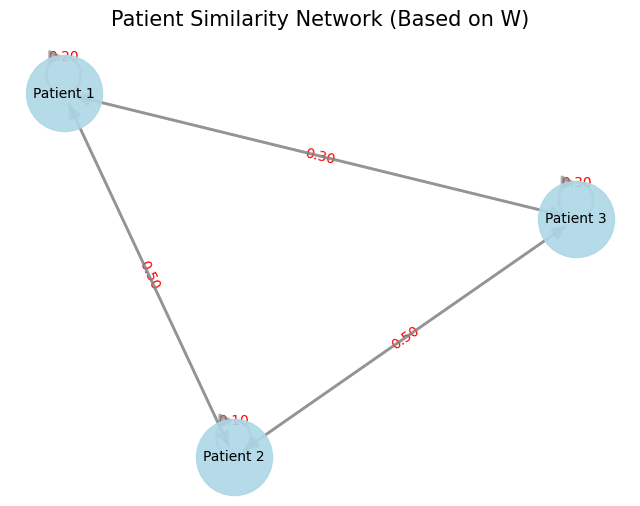

In [3]:
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G)
nx.draw_networkx_nodes(G, pos, node_size=3000, node_color='lightblue', alpha=0.9)
edges = G.edges(data=True)
edgelabels = {(u, v): f'{d["weight"]:.2f}' for u, v, d in edges}
node_labels = {node: node for node in G.nodes()}
nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=10)
nx.draw_networkx_edge_labels(G, pos, edge_labels=edgelabels, font_color='red')
nx.draw_networkx_edges(G, pos, edgelist=edges, arrowsize=20, width=2, alpha=0.6, edge_color='gray')
plt.title('Patient Similarity Network (Based on W)', size=15); plt.axis('off'); plt.show()

---

## **What do the results say of the Equilibrium Risk Vector**

The computed equilibrium risk vector reflects three major components:

- **Individual baseline risk**
- **Propagated influence from similar patients**
- **Network structure effects**

Together, these elements reveal how risk flows through the patient similarity network and stabilizes into a meaningful equilibrium.

---

# Insights from the Patient Similarity Network

### **Nodes and Baseline Risk**
Each node represents a patient. Although the baseline risks are not displayed directly on the graph, the baseline vector \( b \) tells us:

- Patient 1: baseline risk **0.6**
- Patient 2: baseline risk **0.2**
- Patient 3: baseline risk **0.9**

Patient 3 begins with the highest intrinsic risk.

---

### **Directed Edges and Influence**
Arrows represent **directed influence** between patients.

- An arrow from Patient A to Patient B means **Patient A influences Patient B**.
- The matrix entry \( W[i, j] \) indicates **how much patient j influences patient i**.
- Thus, arrows always point **toward the patient being influenced**.

This directionality is helps us understand how risk propagates.

---

### **Edge Weights and Strength of Influence**
Edge labels (weights) quantify the strength of influence:

- **Patient 1**  
  - Strongly influenced by Patient 2 (**0.5**)  
  - Moderately influenced by Patient 3 (**0.3**)  

- **Patient 2**  
  - Strongly influenced by Patient 1 (**0.4**)  
  - Strongly influenced by Patient 3 (**0.5**)  

- **Patient 3**  
  - Moderately influenced by Patient 1 (**0.3**)  
  - Moderately influenced by Patient 2 (**0.4**)  

These weights shape how risk flows through the network.

---

### **Network Structure**
This is a **fully connected directed graph**, meaning:

- Every patient influences every other patient to some degree.
- Self-loops (if included) represent internal reinforcement or intrinsic factors.
- Some relationships exert stronger influence than others, making certain pathways more critical in risk propagation.

The structure determines how quickly and strongly risk spreads.

---

## Summary

The graph provides a visual explanation of how **baseline risk** and **network influence** combine to produce the final equilibrium risk values.

- **Patient 3**, with the highest baseline risk, exerts strong influence on Patient 2, raising Patient 2’s overall risk beyond its low baseline.
- **Patient 1**, despite a moderate baseline, receives substantial influence from both Patient 2 (**0.5**) and Patient 3 (**0.3**), elevating its equilibrium risk.
- **Patient 2** begins with the lowest baseline but is strongly influenced by both other patients, increasing its final risk.

The equilibrium risk vector therefore reflects not only individual health factors but also the **collective dynamics** of the patient network.
